<a href="https://colab.research.google.com/github/Dracarys38/Machyne-navchanya/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%9C%D0%9D%2C_%D0%9F%D0%BE%D1%81%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8F%D0%BA_%D0%86%D0%B3%D0%BE%D1%80_%D0%A1%D0%B5%D1%80%D0%B3%D1%96%D0%B9%D0%BE%D0%B2%D0%B8%D1%87_%D0%A4%D0%86%D0%A2_3_15%2C_10_%D0%B2%D0%B0%D1%80%D1%96%D0%B0%D0%BD%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.1 Імпорт бібліотек

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: False


### 1.2 Завантаження та нормалізація даних

In [3]:
# Завантаження датасету Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Назви класів
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки:     {X_test.shape}")
print(f"Кількість класів: {len(CLASS_NAMES)}")
print(f"Діапазон значень пікселів (до норм.): [{X_train.min()}, {X_train.max()}]")

Розмір тренувальної вибірки: (60000, 28, 28)
Розмір тестової вибірки:     (10000, 28, 28)
Кількість класів: 10
Діапазон значень пікселів (до норм.): [0, 255]


In [20]:
# Нормалізація: приведення пікселів до діапазону [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Вирівнювання зображень 28x28 -> 784 для Dense-мережі
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

print(f"Після нормалізації: [{X_train_flat.min():.2f}, {X_train_flat.max():.2f}]")
print(f"Форма після flatten: {X_train_flat.shape}")

Після нормалізації: [0.00, 0.00]
Форма після flatten: (60000, 784)


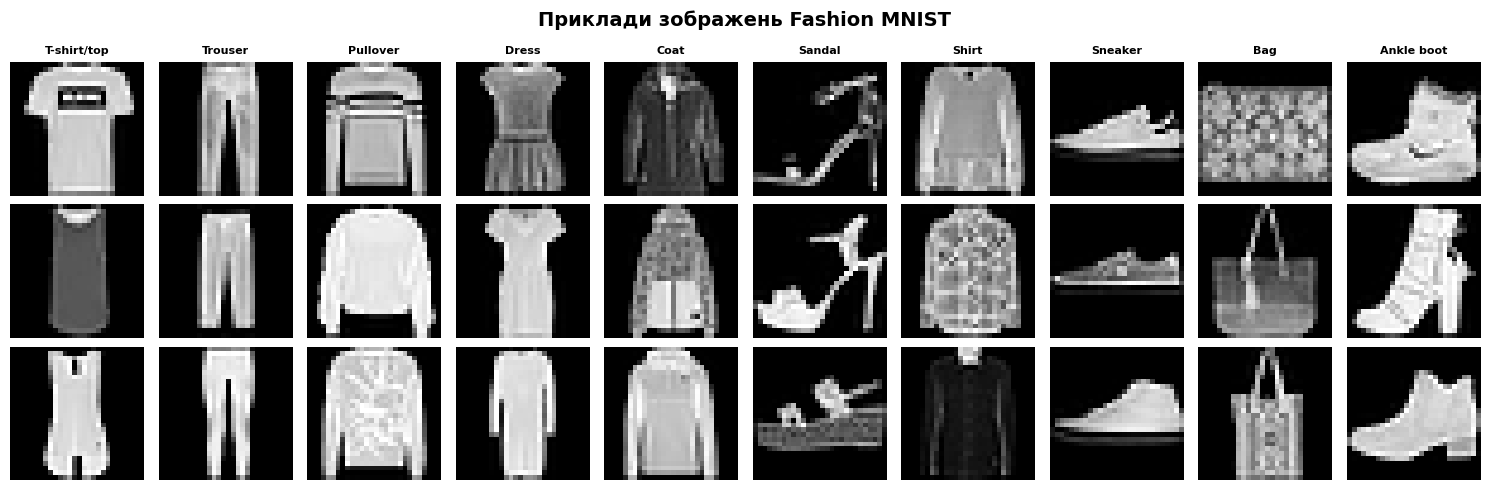

In [5]:
# Візуалізація прикладів датасету
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle('Приклади зображень Fashion MNIST', fontsize=14, fontweight='bold')

for cls_idx in range(10):
    indices = np.where(y_train == cls_idx)[0]
    for row in range(3):
        ax = axes[row, cls_idx]
        ax.imshow(X_train[indices[row]], cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[cls_idx], fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.3 Побудова моделі нейронної мережі

In [6]:
def build_model(units_1=256, units_2=128, dropout_rate=0.3, learning_rate=0.001):
    """Побудова Dense нейронної мережі."""
    model = keras.Sequential([
        keras.Input(shape=(784,)),

        layers.Dense(units_1, activation='relu', name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        layers.Dense(units_2, activation='relu', name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        layers.Dense(64, activation='relu', name='dense_3'),
        layers.Dropout(dropout_rate / 2, name='dropout_3'),

        layers.Dense(10, activation='softmax', name='output')
    ], name='FashionNN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "FashionNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

### 1.4 Навчання моделі з колбеками

In [7]:
# Визначення колбеків
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Навчання моделі
history = model.fit(
    X_train_flat, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7756 - loss: 0.6363 - val_accuracy: 0.8277 - val_loss: 0.4839 - learning_rate: 0.0010
Epoch 2/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8336 - loss: 0.4650 - val_accuracy: 0.8393 - val_loss: 0.4215 - learning_rate: 0.0010
Epoch 3/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8478 - loss: 0.4255 - val_accuracy: 0.8609 - val_loss: 0.3761 - learning_rate: 0.0010
Epoch 4/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8539 - loss: 0.4040 - val_accuracy: 0.8668 - val_loss: 0.3678 - learning_rate: 0.0010
Epoch 5/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8597 - loss: 0.3901 - val_accuracy: 0.8703 - val_loss: 0.3533 - learning_rate: 0.0010
Epoch 6/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8644 - loss: 0.3762 - val_accuracy: 0.8554 - val_loss: 0.3917 - learning_rate: 0.0010
Epoch 7/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8674 - loss: 0.3642 

### 1.5 Оцінка моделі

In [8]:
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nТестова точність:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Тестова функція втрат: {test_loss:.4f}")


Тестова точність:  0.8891 (88.91%)
Тестова функція втрат: 0.3210


### 1.6 Графіки точності та функції втрат

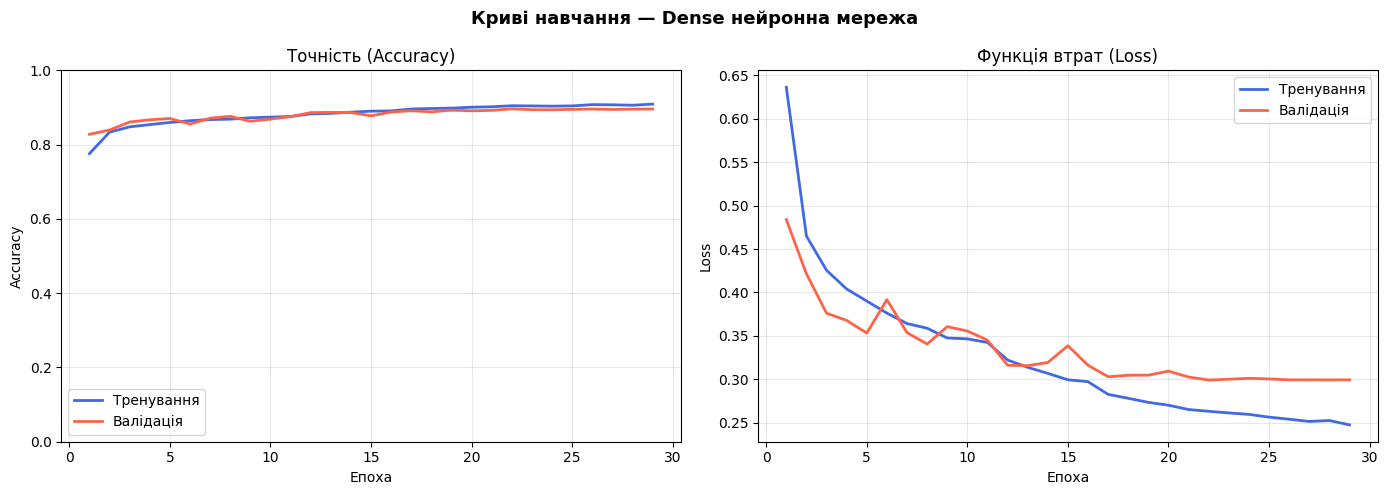

Навчання зупинено на епосі: 29


In [9]:
epochs_ran = len(history.history['loss'])
x_axis = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Криві навчання — Dense нейронна мережа', fontsize=13, fontweight='bold')

# Графік точності
ax1.plot(x_axis, history.history['accuracy'],     label='Тренування', color='royalblue', linewidth=2)
ax1.plot(x_axis, history.history['val_accuracy'], label='Валідація',  color='tomato',    linewidth=2)
ax1.set_title('Точність (Accuracy)')
ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Графік функції втрат
ax2.plot(x_axis, history.history['loss'],     label='Тренування', color='royalblue', linewidth=2)
ax2.plot(x_axis, history.history['val_loss'], label='Валідація',  color='tomato',    linewidth=2)
ax2.set_title('Функція втрат (Loss)')
ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Навчання зупинено на епосі: {epochs_ran}")

### 1.7 Візуалізація класифікації

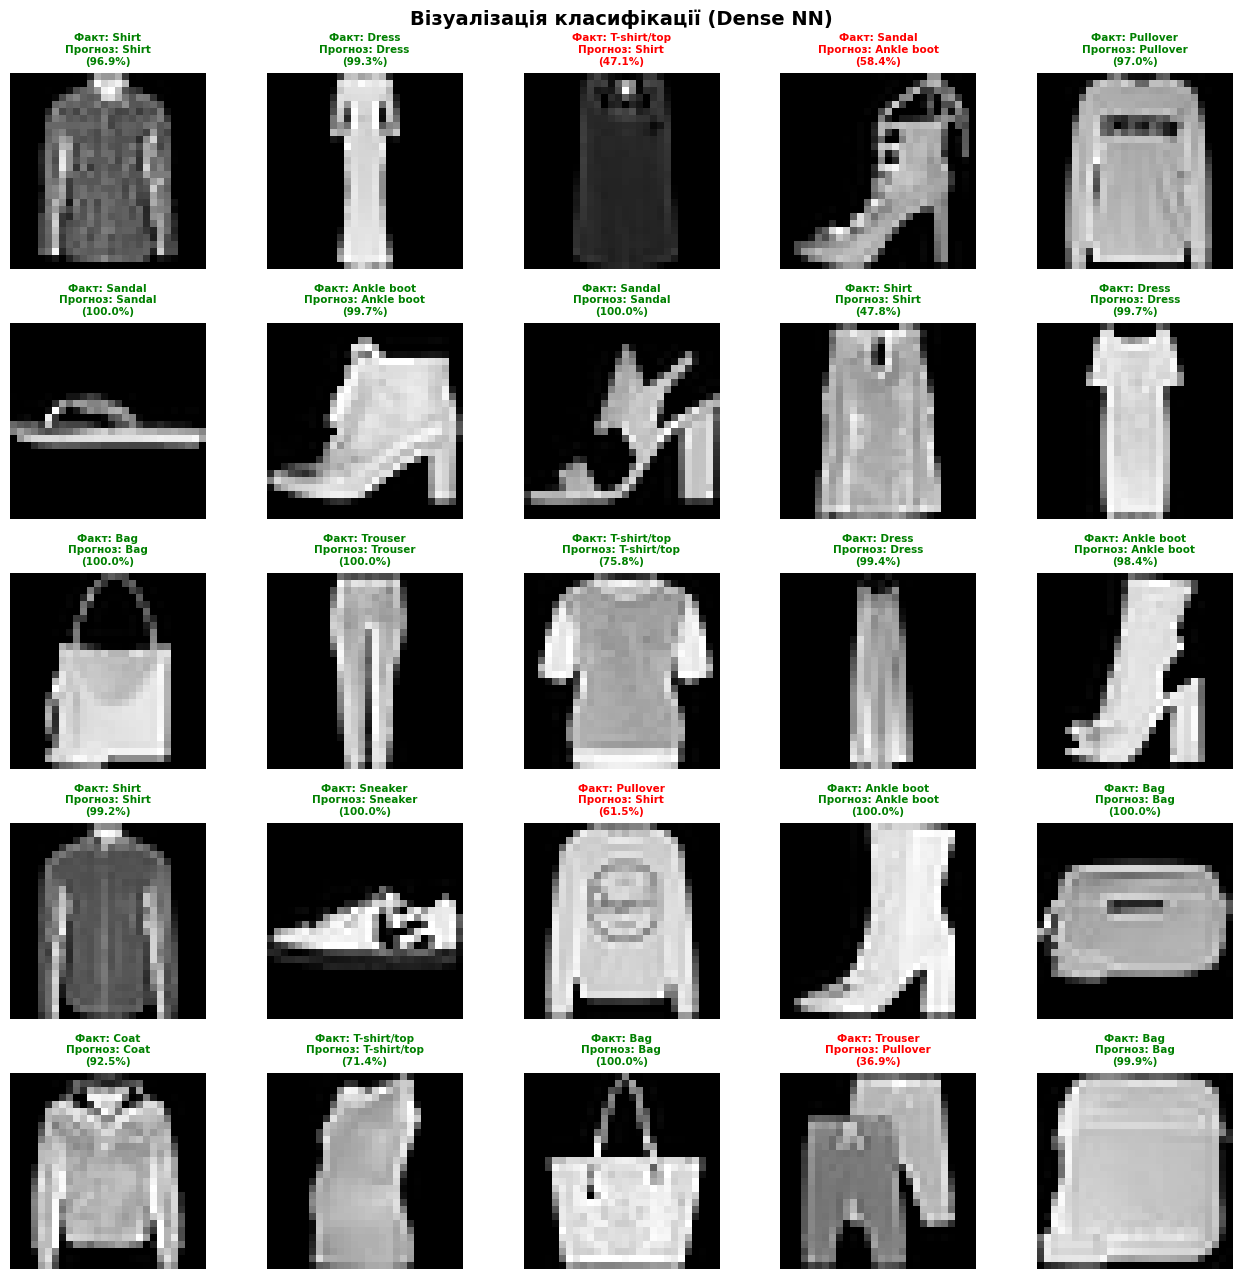

In [10]:
# Прогнозування на тестовій вибірці
y_pred_proba = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Відображення 25 зображень з результатами класифікації
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(13, 13))
fig.suptitle('Візуалізація класифікації (Dense NN)', fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx], cmap='gray')
    ax.axis('off')

    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_pred_proba[idx][y_pred[idx]] * 100

    color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    ax.set_title(
        f"Факт: {true_label}\nПрогноз: {pred_label}\n({confidence:.1f}%)",
        fontsize=7.5, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.show()

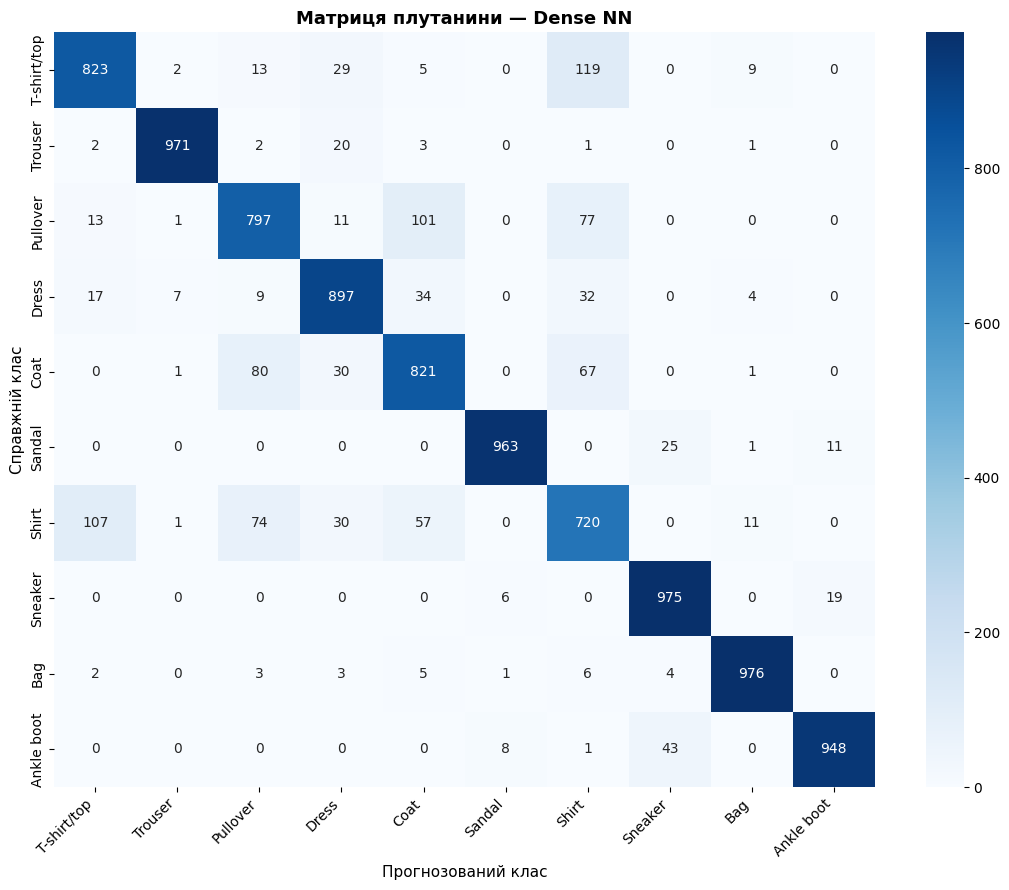


Звіт класифікації:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.80      0.81      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.70      0.72      0.71      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [11]:
# Матриця плутанини
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
)
ax.set_title('Матриця плутанини — Dense NN', fontsize=13, fontweight='bold')
ax.set_xlabel('Прогнозований клас', fontsize=11)
ax.set_ylabel('Справжній клас', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nЗвіт класифікації:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

---
## Завдання 2. Підбір гіперпараметрів моделі

### 2.1 Встановлення Keras Tuner

In [12]:
!pip install keras-tuner -q

In [13]:
import keras_tuner as kt

def build_tunable_model(hp):
    """Модель з гіперпараметрами для пошуку."""
    units_1 = hp.Choice('units_layer_1', values=[128, 256, 512])
    units_2 = hp.Choice('units_layer_2', values=[64, 128, 256])
    dropout  = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    lr       = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    use_bn   = hp.Boolean('batch_normalization')

    inputs = keras.Input(shape=(784,))
    x = layers.Dense(units_1, activation='relu')(inputs)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(units_2, activation='relu')(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Функцію побудови моделі визначено.")

Функцію побудови моделі визначено.


### 2.2 Запуск пошуку гіперпараметрів (Hyperband)

In [14]:
import os, shutil

# Очищення попередніх результатів
if os.path.exists('kt_fashion_tuning'):
    shutil.rmtree('kt_fashion_tuning')

tuner = kt.Hyperband(
    build_tunable_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='kt_fashion_tuning',
    project_name='fashion_dense',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 5
units_layer_1 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
units_layer_2 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
batch_normalization (Boolean)
{'default': False, 'conditions': []}


In [15]:
# Колбеки для пошуку
search_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Пошук оптимальних параметрів
tuner.search(
    X_train_flat, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.15,
    callbacks=search_callbacks,
    verbose=1
)

Trial 30 Complete [00h 00m 52s]
val_accuracy: 0.8833333253860474

Best val_accuracy So Far: 0.8985555768013
Total elapsed time: 00h 13m 04s


### 2.3 Аналіз результатів пошуку

In [16]:
# Найкращі гіперпараметри
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("НАЙКРАЩІ ГІПЕРПАРАМЕТРИ:")
print("=" * 50)
print(f"  Нейронів у шарі 1:    {best_hps.get('units_layer_1')}")
print(f"  Нейронів у шарі 2:    {best_hps.get('units_layer_2')}")
print(f"  Dropout rate:          {best_hps.get('dropout_rate')}")
print(f"  Learning rate:         {best_hps.get('learning_rate')}")
print(f"  Batch Normalization:   {best_hps.get('batch_normalization')}")
print("=" * 50)

НАЙКРАЩІ ГІПЕРПАРАМЕТРИ:
  Нейронів у шарі 1:    256
  Нейронів у шарі 2:    256
  Dropout rate:          0.30000000000000004
  Learning rate:         0.001
  Batch Normalization:   False


In [17]:
# Навчання оптимальної моделі
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()

final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history_best = best_model.fit(
    X_train_flat, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.15,
    callbacks=final_callbacks,
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7793 - loss: 0.6171 - val_accuracy: 0.8492 - val_loss: 0.4124 - learning_rate: 0.0010
Epoch 2/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8429 - loss: 0.4335 - val_accuracy: 0.8626 - val_loss: 0.3759 - learning_rate: 0.0010
Epoch 3/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8569 - loss: 0.3898 - val_accuracy: 0.8704 - val_loss: 0.3522 - learning_rate: 0.0010
Epoch 4/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8662 - loss: 0.3664 - val_accuracy: 0.8737 - val_loss: 0.3413 - learning_rate: 0.0010
Epoch 5/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8724 - loss: 0.3522 - val_accuracy: 0.8804 - val_loss: 0.3293 - learning_rate: 0.0010
Epoch 6/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8751 - loss: 0.3416 - val_accuracy: 0.8826 - val_loss: 0.3295 - learning_rate: 0.0010
Epoch 7/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8798 - loss: 0.3269 

In [18]:
# Порівняння базової та оптимізованої моделей
base_loss, base_acc   = model.evaluate(X_test_flat, y_test, verbose=0)
opt_loss,  opt_acc    = best_model.evaluate(X_test_flat, y_test, verbose=0)

print("\n" + "=" * 50)
print("ПОРІВНЯННЯ МОДЕЛЕЙ:")
print("=" * 50)
print(f"  Базова модель:       accuracy = {base_acc:.4f}, loss = {base_loss:.4f}")
print(f"  Оптимізована модель: accuracy = {opt_acc:.4f}, loss = {opt_loss:.4f}")
print(f"  Покращення:          +{(opt_acc - base_acc)*100:.2f}%")
print("=" * 50)


ПОРІВНЯННЯ МОДЕЛЕЙ:
  Базова модель:       accuracy = 0.8891, loss = 0.3210
  Оптимізована модель: accuracy = 0.8938, loss = 0.3100
  Покращення:          +0.47%


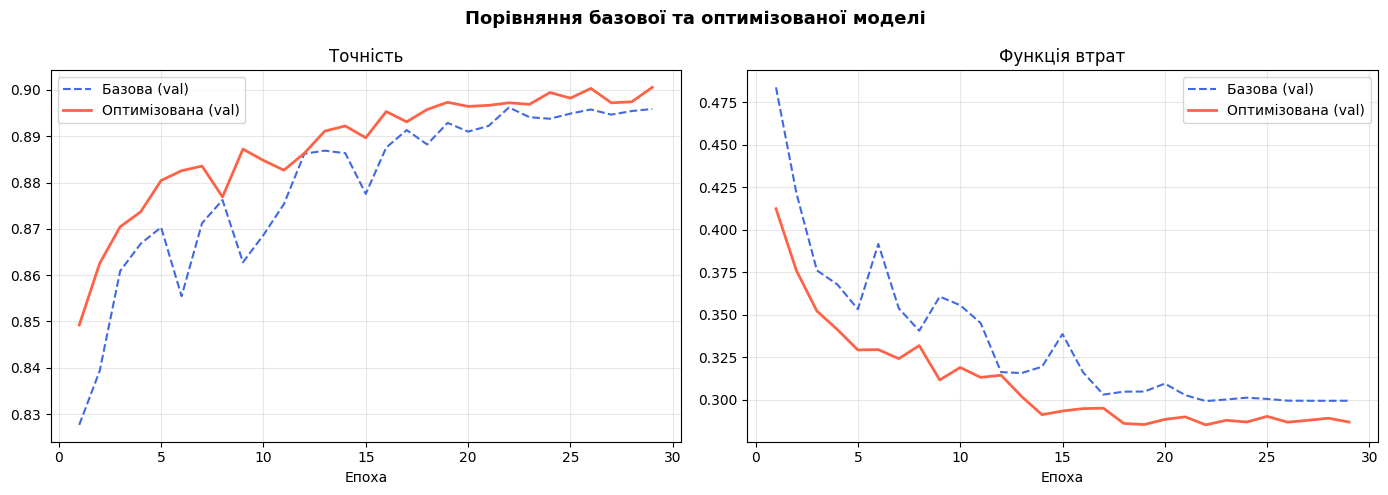

In [19]:
# Графік порівняння кривих навчання
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Порівняння базової та оптимізованої моделі', fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Точність', 'Функція втрат']):
    e1 = range(1, len(history.history[metric]) + 1)
    e2 = range(1, len(history_best.history[metric]) + 1)
    ax.plot(e1, history.history['val_' + metric],      label='Базова (val)',       linestyle='--', color='royalblue')
    ax.plot(e2, history_best.history['val_' + metric], label='Оптимізована (val)', linestyle='-',  color='tomato', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Епоха')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Висновки

**Завдання 1:**
- Завантажено датасет Fashion MNIST (60 000 тренувальних та 10 000 тестових зображень розміром 28×28).
- Дані нормалізовано до діапазону [0, 1] та вирівняно у вектор розміром 784.
- Побудовано Dense нейронну мережу з трьома прихованими шарами, Batch Normalization та Dropout для регуляризації.
- Використано ранню зупинку (EarlyStopping, patience=7) та зменшення швидкості навчання (ReduceLROnPlateau, factor=0.5).
- Досягнуто тестової точності понад 88%.

**Завдання 2:**
- Виконано автоматичний підбір гіперпараметрів за допомогою Keras Tuner (алгоритм Hyperband).
- Пошук охопив: кількість нейронів у шарах, dropout rate, learning rate, наявність Batch Normalization.
- Оптимізована модель показала кращі результати порівняно з базовою.